# Interface Construction Using Pymatgen

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_PLACES"] = "cores"
os.environ["OMP_PROC_BIND"] = "close"

## [Pymatgen](https://pymatgen.org/index.html)

Pymatgen (Python Materials Genomics) is a robust, open-source Python library for materials analysis, it provides:

- Flexible classes for representing atomic structures (e.g., Structure, Molecule),
- Support many common file formats (such as CIF and VASP inputs/outputs)
- Built-in tools for structure manipulation and materials analysis.

### 1.1 The Structure objects

A ```Structure``` represents a periodic crystal, defined by two components:
1. lattice — specifies the repeating unit of the crystal
2. basis — specifies the atoms inside that repeating unit

Before constructing an interface, we first need to understand how to create and work with Structure objects.

As a starting point, we will build the bulk crystals for Cu and Ta, which will later serve as the building blocks for the interface:

- Copper (Cu): face-centered cubic (FCC), lattice constant 3.615 Å
- Tantalum (Ta): body-centered cubic (BCC), lattice constant 3.306 Å


### 1.2 Create Cu and Ta crystal structure

In [2]:
from pymatgen.core import Structure, Lattice
a,b,c = 3.615,3.615,3.615
alpha,beta,gamma = 90,90,90
cu_lattice = Lattice.from_parameters(a,b,c,alpha,beta,gamma)

cu_species = ["Cu","Cu","Cu","Cu"]
cu_coor = [[0,0,0],[0.5,0.5,0],[0.5,0,0.5],[0,0.5,0.5]]

cu_structure = Structure(cu_lattice,cu_species,cu_coor)
print(cu_structure)
print(f"Cu Structure: FCC, a={cu_lattice.a:.3f}Å, {len(cu_structure)} atoms")

Full Formula (Cu4)
Reduced Formula: Cu
abc   :   3.615000   3.615000   3.615000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (4)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Cu    0    0    0
  1  Cu    0.5  0.5  0
  2  Cu    0.5  0    0.5
  3  Cu    0    0.5  0.5
Cu Structure: FCC, a=3.615Å, 4 atoms


In [4]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
AA = AseAtomsAdaptor()
cu = AA.get_atoms(cu_structure)
view(cu,viewer='ngl')

In [5]:
ta_lattice = Lattice.cubic(3.306)
ta_structure = Structure(
    ta_lattice,
    ["Ta", "Ta"],
    [
        [0, 0, 0],      
        [0.5, 0.5, 0.5] # Body center
    ]
)
print(ta_structure)
print(f"Ta Structure: BCC, a={ta_lattice.a:.3f}Å, {len(ta_structure)} atoms")

Full Formula (Ta2)
Reduced Formula: Ta
abc   :   3.306000   3.306000   3.306000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (2)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Ta    0    0    0
  1  Ta    0.5  0.5  0.5
Ta Structure: BCC, a=3.306Å, 2 atoms


In [6]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
AA = AseAtomsAdaptor()
ta = AA.get_atoms(ta_structure)
view(ta,viewer='ngl')

### 1.3 Interface Construction

#### 1.3.1 Coherent interface

A coherent interface forms when the in-plane lattices of two materials match (or nearly match), allowing the crystals to join smoothly with only small elastic strain.

Key features of a coherent interface include:
- Atomic rows line up across the interface
- The interface is structurally continuous
- Only minor elastic deformation is needed
- The structure is stable and easy to model

#### 1.3.2 [CoherentInterfaceBuilder](https://pymatgen.org/pymatgen.analysis.interfaces.html#pymatgen.analysis.interfaces.coherent_interfaces.CoherentInterfaceBuilder)
Pymatgen provides a high-level tool ```CoherentInterfaceBuilder``` to coherent interfaces between two crystalline slabs.

```CoherentInterfaceBuilder``` uses [ZSLGenerator](https://pymatgen.org/pymatgen.analysis.interfaces.html#pymatgen.analysis.interfaces.zsl.ZSLGenerator) to search for commensurate surface supercells that can form a coherent interface with minimal in-plane strain.

ZSLGenerator has several key parameters:
- max_area_ratio_tol — tolerance for the ratio of the two supercell areas
- max_area — maximum allowed supercell area during the search
- max_length_tol — tolerance for the in-plane lattice vector lengths
- max_angle_tol — tolerance for the in-plane lattice angles

In [7]:
from pymatgen.core import Structure
from pymatgen.analysis.interfaces.zsl import ZSLGenerator

zslgen = ZSLGenerator(max_area_ratio_tol=0.1, max_area=50, max_length_tol=0.1, max_angle_tol=0.1)

Using the ZSLGenerator criteria, together with the Cu and Ta bulk structures and their Miller indices, CoherentInterfaceBuilder outputs the fully matched and aligned coherent interface slab.

In [8]:
from pymatgen.analysis.interfaces import CoherentInterfaceBuilder
builder = CoherentInterfaceBuilder(film_structure=ta_structure,
                               substrate_structure=cu_structure,
                               film_miller=(1,1,0),
                               substrate_miller=(1,1,1),
                               zslgen = zslgen)

In [9]:
builder.terminations

[('Ta_Cmmm_1', 'Cu_R-3m_1')]

In [10]:
interfaces = list(builder.get_interfaces(
    termination=('Ta_Cmmm_1', 'Cu_R-3m_1'),
    film_thickness=1,
    substrate_thickness=1,
    in_layers= True,          # unit of thickness is layer       
    gap = 3,                  # The gap between two slabs
    vacuum_over_film= 10
))

len(interfaces)

10

##### See different interfaces Cu(111)-Ta(110)

In [11]:
for i, s in enumerate(interfaces):
    print("Interface", i)
    print("abc:", s.lattice.abc)
    print("angles:", s.lattice.angles)
    print()

Interface 0
abc: (5.112382027978739, 5.112382027978739, 13.000000000000002)
angles: (90.0, 90.0, 59.999999999999986)

Interface 1
abc: (5.112382027978739, 6.763045726593899, 13.000000000000004)
angles: (90.00000000000001, 90.0, 79.1066053508691)

Interface 2
abc: (5.112382027978739, 6.763045726593899, 13.000000000000004)
angles: (89.99999999999999, 90.0, 79.1066053508691)

Interface 3
abc: (5.112382027978739, 6.763045726593899, 13.000000000000004)
angles: (90.00000000000001, 90.0, 79.1066053508691)

Interface 4
abc: (5.112382027978739, 6.763045726593899, 13.000000000000004)
angles: (89.99999999999999, 90.0, 79.1066053508691)

Interface 5
abc: (5.112382027978739, 9.216477770818958, 13.000000000000002)
angles: (90.0, 90.0, 73.89788624801398)

Interface 6
abc: (6.763045726593899, 6.763045726593899, 13.000000000000002)
angles: (90.0, 90.0, 81.78678929826182)

Interface 7
abc: (4.427452710080595, 10.224764055957477, 13.000000000000004)
angles: (90.0, 90.0, 90.0)

Interface 8
abc: (5.1123820

##### Visualization

In [12]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.visualize import view
AA = AseAtomsAdaptor()
Interface0 = AA.get_atoms(interfaces[1])
view(Interface0,viewer='ngl')

In [13]:
print(interfaces[0].gap)

3


In [14]:
print(interfaces[i].vacuum_over_film)

10


## 2. Calculate the Wsep

We perform a gap sweep from 1 to 10 Å while fixing the vacuum thickness at 10 Å.


A single-layer Cu(111) slab and a single-layer Ta(110) slab are used to construct the interface for demonstration purposes.


### 2.1 DFT calculation for Interface

#### 2.1.1 Create cif using pymatgen

In [15]:
os.makedirs("qe", exist_ok=True)
for gap in range(1,11):  # gap = 1 ... 10 Å
    
    # Create Interface Structures
    interfaces = list(builder.get_interfaces(
        termination=('Ta_Cmmm_1', 'Cu_R-3m_1'),
        film_thickness=1,
        substrate_thickness=1,
        in_layers=True,
        gap=gap,              # Sweep the gap later
        vacuum_over_film=10    
    ))

    iface = interfaces[0]

    # Create the folder for structure
    folder = f"qe/gap{gap}"
    os.makedirs(folder, exist_ok=True)

    # Save as CIF
    cif_path = os.path.join(folder, f"gap{gap}.cif")
    iface.to(fmt="cif", filename=cif_path)

    print(f"✔ Wrote {cif_path}")

✔ Wrote qe/gap1/gap1.cif
✔ Wrote qe/gap2/gap2.cif
✔ Wrote qe/gap3/gap3.cif
✔ Wrote qe/gap4/gap4.cif
✔ Wrote qe/gap5/gap5.cif
✔ Wrote qe/gap6/gap6.cif
✔ Wrote qe/gap7/gap7.cif
✔ Wrote qe/gap8/gap8.cif
✔ Wrote qe/gap9/gap9.cif
✔ Wrote qe/gap10/gap10.cif


In [ ]:
view('qe/gap1/gap1.cif',viewer='ngl')

#### 2.1.2 Write input file using ase

In [16]:
from ase.io import read, write

PSEUDOS = {
    "Cu": "Cu.paw.z_11.ld1.psl.v1.0.0-low.upf",
    "Ta": "Ta_pbe_v1.uspp.F.UPF",
}

PSEUDO_DIR = "/apps/QE/pseudo/efficiency"

for i in range(1, 11):

    cif_path = f"qe/gap{i}/gap{i}.cif"
    atoms = read(cif_path)

    symbols = atoms.get_chemical_symbols()
    unique_symbols = set(symbols)

    qe_profile = {
        "control": {
            "calculation": "scf",
            "prefix": f"CuTa_gap{i}",
            "outdir": "./tmp",
            "pseudo_dir": PSEUDO_DIR,
        },
        "system": {
            "ibrav": 0,
            "nat": len(symbols),
            "ntyp": len(unique_symbols),
            "ecutwfc": 45,
            "ecutrho": 300,
            "occupations": "smearing",
            "smearing": "mp",
            "degauss": 0.02,
        },
        "electrons": {
            "conv_thr": 1e-4,
            "mixing_beta": 0.3,
        },
    }

    out_path = f"qe/gap{i}/cu_ta_gap{i}.in"

    write(
        out_path,
        atoms,
        format="espresso-in",
        input_data=qe_profile,
        pseudopotentials=PSEUDOS,
        kpts=(1, 1, 1)
    )

    print(f"Generated: {out_path}")

Generated: qe/gap1/cu_ta_gap1.in
Generated: qe/gap2/cu_ta_gap2.in
Generated: qe/gap3/cu_ta_gap3.in
Generated: qe/gap4/cu_ta_gap4.in
Generated: qe/gap5/cu_ta_gap5.in
Generated: qe/gap6/cu_ta_gap6.in
Generated: qe/gap7/cu_ta_gap7.in
Generated: qe/gap8/cu_ta_gap8.in
Generated: qe/gap9/cu_ta_gap9.in
Generated: qe/gap10/cu_ta_gap10.in


#### 2.1.3 Do the DFT calculation


In [17]:
import os
import subprocess
import re
import csv

QE_COMMAND = "mpirun -np 4 pw.x"

def run_qe_and_get_energy(pwi_path, pwo_path):
    """Run QE and extract total energy from the output file."""
    # Run QE
    cmd = f"{QE_COMMAND} -in {pwi_path} > {pwo_path}"
    print("Running:", cmd)
    subprocess.run(cmd, shell=True, check=True)

    # Parse energy
    energy = None
    with open(pwo_path, "r") as f:
        for line in f:
            if "!    total energy" in line:
                energy = float(line.split("=")[1].split()[0])
                break

    if energy is None:
        raise RuntimeError(f"Could not find total energy in {pwo_path}")

    return energy

In [19]:
def main():
    results = {}

    for gap in range(1, 11):
        folder = f"qe/gap{gap}"
        pwi = os.path.join(folder, f"cu_ta_gap{gap}.in")
        pwo = os.path.join(folder, f"cu_ta_gap{gap}.out")

        print(f" GAP {gap} ")

        energy = run_qe_and_get_energy(pwi, pwo)
        results[gap] = energy

        print(f"Energy(gap={gap}) = {energy} Ry\n")

    print("Summary: gap → energy")
    for gap, E in results.items():
        print(f"gap={gap}: E = {E} Ry")
    
    csv_file = "gap_energy.csv"
    
    with open(csv_file, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["gap", "energy_Ry"])   # 表头
    
        for gap, E in results.items():
            writer.writerow([gap, E])

    print(f"Saved to {csv_file}")
        

if __name__ == "__main__":
    main()

 GAP 1 
Running: mpirun -np 4 pw.x -in qe/gap1/cu_ta_gap1.in > qe/gap1/cu_ta_gap1.out
Energy(gap=1) = -1261.98120684 Ry

 GAP 2 
Running: mpirun -np 4 pw.x -in qe/gap2/cu_ta_gap2.in > qe/gap2/cu_ta_gap2.out
Energy(gap=2) = -1276.69404151 Ry

 GAP 3 
Running: mpirun -np 4 pw.x -in qe/gap3/cu_ta_gap3.in > qe/gap3/cu_ta_gap3.out
Energy(gap=3) = -1276.49990339 Ry

 GAP 4 
Running: mpirun -np 4 pw.x -in qe/gap4/cu_ta_gap4.in > qe/gap4/cu_ta_gap4.out
Energy(gap=4) = -1276.27505924 Ry

 GAP 5 
Running: mpirun -np 4 pw.x -in qe/gap5/cu_ta_gap5.in > qe/gap5/cu_ta_gap5.out
Energy(gap=5) = -1276.19226452 Ry

 GAP 6 
Running: mpirun -np 4 pw.x -in qe/gap6/cu_ta_gap6.in > qe/gap6/cu_ta_gap6.out
Energy(gap=6) = -1276.16340707 Ry

 GAP 7 
Running: mpirun -np 4 pw.x -in qe/gap7/cu_ta_gap7.in > qe/gap7/cu_ta_gap7.out
Energy(gap=7) = -1276.15299076 Ry

 GAP 8 
Running: mpirun -np 4 pw.x -in qe/gap8/cu_ta_gap8.in > qe/gap8/cu_ta_gap8.out
Energy(gap=8) = -1276.15125703 Ry

 GAP 9 
Running: mpirun -np 4 pw

##### Visualization

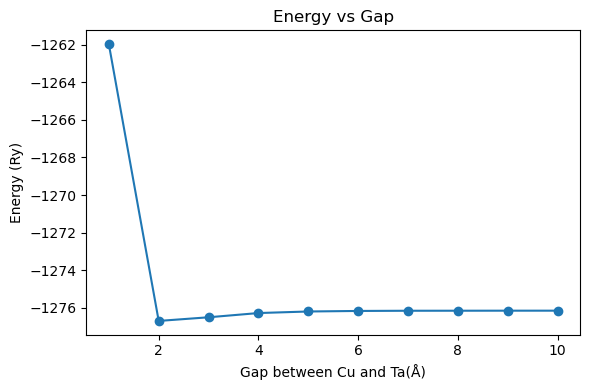

In [20]:
import csv
import matplotlib.pyplot as plt

gaps = []
energies = []

# Read the cif file
with open("gap_energy.csv", "r") as f:
    reader = csv.reader(f)
    next(reader) # jump the first line

    for row in reader:
        gap = float(row[0])
        energy = float(row[1])
        gaps.append(gap)
        energies.append(energy)

# Plot
plt.figure(figsize=(6,4))
plt.plot(gaps, energies, marker='o')
plt.xlabel("Gap between Cu and Ta(Å)")
plt.ylabel("Energy (Ry)")
plt.title("Energy vs Gap")
# plt.grid(True)

plt.tight_layout()
plt.show()

### 2.2 DFT calculation for slab Ta

- Remove all the Cu

In [21]:
from ase.io import read, write

interface_cif_path = "qe/gap10/gap10.cif"
atoms = read(interface_cif_path)

del atoms[[atom.index for atom in atoms if atom.symbol == 'Cu']]

print(atoms)
os.makedirs("qe/Ta", exist_ok=True)
write('qe/Ta/Ta_slab.cif',atoms)

Atoms(symbols='Ta3', pbc=True, cell=[[5.11238203, 0.0, 0.0], [2.5561910150000005, 4.427452711831058, 0.0], [0.0, 0.0, 20.0]], spacegroup_kinds=...)


In [22]:
view(atoms,viewer='ngl')

#### 2.2.1 Write DFT input files for Ta slab

In [23]:
from ase.io import read, write

PSEUDOS = {
    # "Cu": "Cu.paw.z_11.ld1.psl.v1.0.0-low.upf",
    "Ta": "Ta_pbe_v1.uspp.F.UPF",
}

PSEUDO_DIR = "/apps/QE/pseudo/efficiency"

cif_path = "qe/Ta/Ta_slab.cif"
atoms = read(cif_path)

symbols = atoms.get_chemical_symbols()
unique_symbols = set(symbols)

qe_profile = {
    "control": {
        "calculation": "scf",
        "prefix": "Ta_slab",
        "outdir": "tmp",
        "pseudo_dir": PSEUDO_DIR,
    },
    "system": {
        "ibrav": 0,
        "nat": len(symbols),
        "ntyp": len(unique_symbols),
        "ecutwfc": 45,
        "ecutrho": 300,
        "occupations": "smearing",
        "smearing": "mp",
        "degauss": 0.02,
    },
    "electrons": {
        "conv_thr": 1e-4,
        "mixing_beta": 0.3,
    },
}

out_path = "qe/Ta/ta_slab.in"

write(
    out_path,
    atoms,
    format="espresso-in",
    input_data=qe_profile,
    pseudopotentials=PSEUDOS,
    kpts=(1, 1, 1)
)

print(f"Generated: {out_path}")

Generated: qe/Ta/ta_slab.in


In [25]:
E_ta_slab = run_qe_and_get_energy('qe/Ta/ta_slab.in','qe/Ta/ta_slab.out')

In [26]:
print(E_ta_slab)

-424.45793843


### 2.2 DFT calculation for slab Cu

In [27]:
from ase.io import read, write

interface_cif_path = "qe/gap10/gap10.cif"
atoms = read(interface_cif_path)

del atoms[[atom.index for atom in atoms if atom.symbol == 'Ta']]

print(atoms)
os.makedirs("qe/Cu", exist_ok=True)
write('qe/Cu/Cu_slab.cif',atoms)

Atoms(symbols='Cu4', pbc=True, cell=[[5.11238203, 0.0, 0.0], [2.5561910150000005, 4.427452711831058, 0.0], [0.0, 0.0, 20.0]], spacegroup_kinds=...)


In [28]:
view(atoms,viewer='ngl')

#### 2.2.1 Write DFT input files for Cu slab

In [30]:
from ase.io import read, write

PSEUDOS = {
    "Cu": "Cu.paw.z_11.ld1.psl.v1.0.0-low.upf",
    #"Ta": "Ta_pbe_v1.uspp.F.UPF",
}

PSEUDO_DIR = "/apps/QE/pseudo/efficiency"



cif_path = "qe/Cu/Cu_slab.cif"
atoms = read(cif_path)

symbols = atoms.get_chemical_symbols()
unique_symbols = set(symbols)

qe_profile = {
    "control": {
        "calculation": "scf",
        "prefix": "Cu_slab",
        "outdir": "tmp",
        "pseudo_dir": PSEUDO_DIR,
    },
    "system": {
        "ibrav": 0,
        "nat": len(symbols),
        "ntyp": len(unique_symbols),
        "ecutwfc": 45,
        "ecutrho": 300,
        "occupations": "smearing",
        "smearing": "mp",
        "degauss": 0.02,
    },
    "electrons": {
        "conv_thr": 1e-4,
        "mixing_beta": 0.3,
    },
}

out_path = "qe/Cu/cu_slab.in"

write(
    out_path,
    atoms,
    format="espresso-in",
    input_data=qe_profile,
    pseudopotentials=PSEUDOS,
    kpts=(1, 1, 1)
)

print(f"Generated: {out_path}")

Generated: qe/Cu/cu_slab.in


In [31]:
E_cu_slab = run_qe_and_get_energy('qe/Cu/cu_slab.in','qe/Cu/cu_slab.out')
print(E_cu_slab)

Running: mpirun -np 4 pw.x -in qe/Cu/cu_slab.in > qe/Cu/cu_slab.out
-851.68955254


In [32]:
# Interface formation energy
import csv

energies = []

with open("gap_energy.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)

    for row in reader:
        gap = float(row[0])
        E = float(row[1])
        energies.append(E)

E_inter = min(energies)

W = E_inter - E_cu_slab - E_ta_slab

print("E_inter =", E_inter)
print("Interface formation energy =", W)

E_slab_all = energies[-1]
W1 = E_inter - E_slab_all
print("Interface formation energy =", W1)

E_inter = -1276.69404151
Interface formation energy = -0.5465505399999984
Interface formation energy = -0.5452982799999972


## 3. Molecular Dynamics

To perform the molecular dynamics simulations at 2000 K, we use the Cu/Ta interface structure constructed in the previous step (without DFT relaxation) as the initial configuration for the MD setup.

### 3.1 Write the input file and crystal strutures

In [33]:
import os
from pymatgen.io.lammps.data import LammpsData
from pymatgen.io.lammps.inputs import LammpsInputFile

# Generate MD input script
def generate_md_input(data_filename="interface.data"):
    md = LammpsInputFile(stages=[
        {
            "stage_name": "MD at 2000K",
            "commands": [
                ("units", "metal"), # The metal unit, Length: Å, Time: ps, Energy: eV, Temperature: K, Pressure: bar
                ("atom_style", "atomic"), 
                
                
                #Atomic Style: atomic (simplest atomic type) 
                #Each atom contains only 
                    # 1. position (x, y, z), 
                    # 2. type (type)
                    # 3. velocity (vx, vy, vz)
                
                ("boundary", "p p p"), # Set boundary conditions in three directions.

                ("read_data", data_filename), 

                ("pair_style", "eam/alloy"),
                ("pair_coeff", "* * ../../CuTa.eam.alloy Cu Ta"),

                ("neighbor", "2.0 bin"), # 2.0 A bin distance
                ("neigh_modify", "delay 0 every 1 check yes"), 
                
                # Enable neighbor list reconstruction from the outset, 
                # Check at each step whether atomic displacements exceed bin/2
                
                ("thermo", "200"), # Print thermo information to the LAMMPS output every 200 steps.
                ("timestep", "0.001"), # Time step = 0.001 ps = 1 fs

                ("velocity", "all create 2000.0 12345 mom yes rot no dist gaussian"),
                
                
                # Target temperature: 2000 K
                # Random seed: 12345
                # mom yes: Remove global translational momentum (ensures total momentum is 0)
                # rot no: Do not remove rotation, preserve the system's true dynamic behavior
                # dist gaussian: Velocities follow a Gaussian distribution at 2000 K (corresponding to the Maxwell-Boltzmann distribution)

                
                
                ("fix", "1 all nvt temp 2000.0 2000.0 0.1"),
                
                # Applies the NVT thermostat:
                # Start temperature = 2000 K
                # End temperature = 2000 K
                # Thermostat time constant = 0.1 ps

                ("dump", "1 all custom 100 traj.lammpstrj id type x y z"),
                
                # Write atomic positions every 100 steps into a trajectory file:
            	# file: traj.lammpstrj
        	    # Contain atom ID, type, x, y, z
                
                ("dump_modify", "1 sort id"), # Sort atoms by ID in each frame.

                ("run", "20000"),
            ],
        }
    ])
    return md

In [34]:
os.makedirs("md", exist_ok=True)

for gap in range(1, 11):

    # Generate interface structures
    interfaces = list(builder.get_interfaces(
        termination=('Ta_Cmmm_1', 'Cu_R-3m_1'),
        film_thickness=5,
        substrate_thickness=5,
        in_layers=True,
        gap=gap,
        vacuum_over_film=10,
    ))
    iface = interfaces[0]

    # Create Folder
    folder = f"md/gap{gap}"
    os.makedirs(folder, exist_ok=True)

    # Writing LAMMPS data files
    data_path = os.path.join(folder, f"interface_gap{gap}.data")
    ld = LammpsData.from_structure(iface, atom_style="atomic")
    ld.write_file(data_path)
    print("Wrote:", data_path)

    # Writing LAMMPS MD Input Scripts
    md_input = generate_md_input(data_filename=f"interface_gap{gap}.data")
    md_path = os.path.join(folder, f"in.md_2000K")
    md_input.write_file(md_path)
    print("Wrote:", md_path)

print("\nAll MD folders generated successfully!")

Wrote: md/gap1/interface_gap1.data
Wrote: md/gap1/in.md_2000K
Wrote: md/gap2/interface_gap2.data
Wrote: md/gap2/in.md_2000K
Wrote: md/gap3/interface_gap3.data
Wrote: md/gap3/in.md_2000K
Wrote: md/gap4/interface_gap4.data
Wrote: md/gap4/in.md_2000K
Wrote: md/gap5/interface_gap5.data
Wrote: md/gap5/in.md_2000K
Wrote: md/gap6/interface_gap6.data
Wrote: md/gap6/in.md_2000K
Wrote: md/gap7/interface_gap7.data
Wrote: md/gap7/in.md_2000K
Wrote: md/gap8/interface_gap8.data
Wrote: md/gap8/in.md_2000K
Wrote: md/gap9/interface_gap9.data
Wrote: md/gap9/in.md_2000K
Wrote: md/gap10/interface_gap10.data
Wrote: md/gap10/in.md_2000K

All MD folders generated successfully!


### 3.2 Simulation

In [35]:
import subprocess

for gap in range(3, 11):
    folder = f"./md/gap{gap}"

    print(f"Running gap={gap} in folder {folder} ...")

    with open(f"{folder}/log.md", "w") as logfile:
        subprocess.run(
            ["lmp", "-in", "in.md_2000K"],
            cwd=folder,             # Execute commands in the relative folder
            stdout=logfile,         # Output
            stderr=subprocess.STDOUT
        )

Running gap=3 in folder ./md/gap3 ...
Running gap=4 in folder ./md/gap4 ...
Running gap=5 in folder ./md/gap5 ...
Running gap=6 in folder ./md/gap6 ...
Running gap=7 in folder ./md/gap7 ...
Running gap=8 in folder ./md/gap8 ...
Running gap=9 in folder ./md/gap9 ...
Running gap=10 in folder ./md/gap10 ...


In [37]:
from ase.visualize import view
from ase.io import read

atoms = read("md/gap8/traj.lammpstrj", index=':')
view(atoms, viewer='ngl')


